# โครงการวิจัย: การพัฒนาแพลตฟอร์มตรวจสอบเอกลักษณ์ของพรรณไม้ในกลุ่มพืชที่มีเฉพาะถิ่น จังหวัดปทุมธานี
### การประยุกต์ใช้เทคโนโลยีการเรียนรู้เชิงลึก (Deep Learning) ด้วย TensorFlow / Keras บน Google Colab

สมุดบันทึกนี้ออกแบบมาเพื่อจำลองและประเมินผลการเรียนรู้เชิงลึกสำหรับการตรวจสอบเอกลักษณ์พรรณไม้ท้องถิ่นในจังหวัดปทุมธานี เช่น บัวสายพันธุ์ต่าง ๆ, กล้วยหอมทองปทุม, ข้าวหอมปทุมธานี 1 หรือพืชสมุนไพร โดยลอกเลียนขั้นตอนการทำงานมาจากตัวอย่างโมเดลก่อนหน้านี้

# SECTION 1: เชื่อมต่อ Google Drive และโหลดไลบรารีที่จำเป็น

In [1]:
import pandas as pd
import numpy as np
import requests
import os
import json
import shutil
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers

# 1. เชื่อมต่อกับ Google Drive (ยกเลิก Comment เมื่อรันบน Colab จริง)
from google.colab import drive
drive.mount('/content/drive')

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# SECTION 2: ค้นหาและรวบรวมลิงก์รูปภาพพรรณไม้จาก GBIF API (Retrieve Image URLs)

In [ ]:
# 1. กำหนดพาธไฟล์รายชื่อพืชพรรณและไฟล์ผลลัพธ์ลิงก์รูปภาพ
json_path = '/content/drive/MyDrive/Colab Notebooks/plants/data/VRU.json'
local_json_path = 'data/VRU.json'

# ตรวจสอบและเลือกพาธที่มีไฟล์อยู่จริง
selected_path = json_path if os.path.exists(json_path) else (local_json_path if os.path.exists(local_json_path) else None)

# 2. ฟังก์ชันส่งคำขอไปยัง GBIF API เพื่อรวบรวมลิงก์รูปภาพพืช
def fetch_gbif_image_links(dataframe, limit_per_species=100):
    print(f"🔍 เริ่มค้นหาภาพจาก GBIF (ดึงสูงสุด {limit_per_species} รูปภาพต่อพืช 1 ชนิด)...")
    image_records = []
    
    for index, row in dataframe.iterrows():
        scientific_name = row.get('scientific_name', '')
        common_name = row.get('common_name_th', 'Unknown_Plant')
        family = row.get('family', 'Unknown_Family')
        
        if not scientific_name or pd.isna(scientific_name):
            continue
            
        print(f"-> กำลังค้นพืช: {common_name} ({scientific_name}) ", end="")
        
        url = "https://api.gbif.org/v1/occurrence/search"
        params = {
            "scientificName": scientific_name,
            "mediaType": "StillImage",
            "limit": limit_per_species
        }
        
        try:
            response = requests.get(url, params=params, timeout=15)
            if response.status_code == 200:
                data = response.json()
                results = data.get("results", [])
                
                found_count = 0
                for record in results:
                    media_list = record.get("media", [])
                    for media in media_list:
                        if media.get("type") == "StillImage":
                            img_url = media.get("identifier")
                            if img_url:
                                image_records.append({
                                    "common_name_th": common_name,
                                    "scientific_name": scientific_name,
                                    "family": family,
                                    "image_url": img_url
                                })
                                found_count += 1
                                break # ดึงเพียง 1 ลิงก์รูปภาพต่อ 1 Occurrence Record
                print(f"[พบภาพ {found_count} รูป]")
            else:
                print(f"[Error: Server Status {response.status_code}]")
        except Exception as e:
            print(f"[Error: {e}]")
            
    return pd.DataFrame(image_records)

# 3. เรียกใช้งาน (ปลดล็อกเมื่อรันจริงใน Google Colab)
if selected_path:
    df_plants = pd.read_json(selected_path)
    df_images = fetch_gbif_image_links(df_plants, limit_per_species=150)
    
    # ส่งออกลิงก์ภาพพืชที่ดึงได้ไปที่ไฟล์ VRU_image_links.json
    target_links_path = '/content/drive/MyDrive/Colab Notebooks/plants/data/VRU_image_links.json' if selected_path == json_path else 'data/VRU_image_links.json'
    df_images.to_json(target_links_path, orient='records', force_ascii=False, indent=4)
    print(f"\n🎉 บันทึกตารางลิงก์ภาพพืชเรียบร้อยที่: {target_links_path}")
    print(f"📂 พบไฟล์รายชื่อพืชที่: {selected_path} (ระบบดึงลิงก์จาก GBIF API พร้อมรัน)")
else:
    print("⚠️ ไม่พบไฟล์ฐานข้อมูลรายชื่อพืช VRU.json โปรดรัน data.ipynb เพื่อจัดเตรียมก่อน")

# SECTION 3: คัดกรองชนิดพืชที่มีรูปไม่ถึงเกณฑ์ และปรับลดปริมาณภาพที่เกิน (Filter & Cap Image Links)

In [4]:
# 1. กำหนดพาธไฟล์คลังลิงก์ภาพพืชต้นทาง และไฟล์ปลายทางหลังคัดกรอง
links_json_path = '/content/drive/MyDrive/Colab Notebooks/plants/data/VRU_image_links.json'
filtered_json_path = '/content/drive/MyDrive/Colab Notebooks/plants/data/VRU_image_links_filtered.json'
local_links_path = 'data/VRU_image_links.json'
local_filtered_path = 'data/VRU_image_links_filtered.json'

# ตรวจสอบพาธที่มีข้อมูลอยู่จริง
selected_links_path = links_json_path if os.path.exists(links_json_path) else (local_links_path if os.path.exists(local_links_path) else None)

# 2. ฟังก์ชันคัดกรองคลาสพืชที่มีรูปไม่ถึง required_count และจำกัดภาพคลาสที่เกิน
def filter_and_cap_image_links(source_path, target_path, required_count=100):
    if not source_path:
        print("⚠️ ไม่พบไฟล์คลังลิงก์รูปภาพเริ่มต้น")
        return

    print(f"📖 กำลังอ่านข้อมูลคลังลิงก์ภาพจาก: {source_path}")
    with open(source_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # จัดกลุ่มลิงก์แยกตามชื่อชนิดพืช
    species_groups = {}
    for item in data:
        common_name = item.get('common_name_th', 'Unknown')
        if common_name not in species_groups:
            species_groups[common_name] = []
        species_groups[common_name].append(item)

    filtered_records = []
    removed_species = []
    kept_species_count = 0

    print(f"\n--- 🔍 ดำเนินการคัดกรองภาพพืช (เป้าหมาย: คลาสละ {required_count} รูป) ---")
    for common_name, records in species_groups.items():
        total_pics = len(records)
        
        # กรองทิ้งหากมีรูปไม่ถึง required_count รูป
        if total_pics < required_count:
            removed_species.append(f"{common_name} ({total_pics} รูป)")
            continue

        # คัดรูปพืชที่เกิน required_count รูปให้เหลือแค่ required_count รูป
        capped_records = records[:required_count]
        filtered_records.extend(capped_records)
        kept_species_count += 1

    print(f"\n✅ คัดกรองพืชเสร็จสิ้น:")
    print(f" - จำนวนชนิดพืชผ่านเกณฑ์ (มีครบ {required_count} รูปขึ้นไป): {kept_species_count} ชนิด")
    print(f" - จำนวนชนิดพืชที่ถูกคัดทิ้งเนื่องจากมีภาพไม่ถึงเกณฑ์: {len(removed_species)} ชนิด")
    if removed_species:
        print("   (รายชื่อพืชที่ถูกคัดทิ้ง: " + ", ".join(removed_species) + ")")

    # บันทึกเป็น JSON ไฟล์ใหม่
    with open(target_path, 'w', encoding='utf-8') as f:
        json.dump(filtered_records, f, ensure_ascii=False, indent=4)

    print(f"\n🎉 ส่งออกไฟล์ JSON ลิงก์ภาพที่คัดกรองแล้ว (รวมทั้งหมด {len(filtered_records)} ลิงก์) สำเร็จที่: {target_path}")

# 3. เรียกใช้งานการกรองลิงก์ (ปลดล็อกเมื่อรันจริงใน Google Colab)
if selected_links_path:
    target_path = filtered_json_path if selected_links_path == links_json_path else local_filtered_path
    filter_and_cap_image_links(selected_links_path, target_path, required_count=100)
    print(f"📂 พบไฟล์คลังลิงก์ภาพพืชที่: {selected_links_path} (ระบบคัดกรองลิงก์ภาพพร้อมรัน)")
else:
    print("⚠️ ไม่พบไฟล์คลังลิงก์รูปภาพ VRU_image_links.json โปรดรัน Section 2 ก่อน")

📖 กำลังอ่านข้อมูลคลังลิงก์ภาพจาก: /content/drive/MyDrive/Colab Notebooks/plants/data/VRU_image_links.json

--- 🔍 ดำเนินการคัดกรองภาพพืช (เป้าหมาย: คลาสละ 100 รูป) ---

✅ คัดกรองพืชเสร็จสิ้น:
 - จำนวนชนิดพืชผ่านเกณฑ์ (มีครบ 100 รูปขึ้นไป): 166 ชนิด
 - จำนวนชนิดพืชที่ถูกคัดทิ้งเนื่องจากมีภาพไม่ถึงเกณฑ์: 10 ชนิด
   (รายชื่อพืชที่ถูกคัดทิ้ง: กระดังงาสงขลา (23 รูป), แคนา (67 รูป), ชะอม (34 รูป), ชมนาด (99 รูป), ตะแบก (76 รูป), เตยหอม (27 รูป), พิลังกาสา (6 รูป), พุดน้ำบุศย์ (77 รูป), มะดัน (40 รูป), อรพิม (69 รูป))

🎉 ส่งออกไฟล์ JSON ลิงก์ภาพที่คัดกรองแล้ว (รวมทั้งหมด 16600 ลิงก์) สำเร็จที่: /content/drive/MyDrive/Colab Notebooks/plants/data/VRU_image_links_filtered.json
📂 พบไฟล์คลังลิงก์ภาพพืชที่: /content/drive/MyDrive/Colab Notebooks/plants/data/VRU_image_links.json (ระบบคัดกรองลิงก์ภาพพร้อมรัน)


# SECTION 4: ดาวน์โหลดรูปภาพพรรณไม้ที่ผ่านการคัดกรองแล้วลงพื้นที่เก็บข้อมูล (Download Filtered Images)

In [5]:
# 1. กำหนดพาธไฟล์ลิงก์ภาพพืชที่ผ่านการกรองแล้ว และโฟลเดอร์สำหรับบันทึกภาพ
links_json_path = '/content/drive/MyDrive/Colab Notebooks/plants/data/VRU_image_links_filtered.json'
base_download_path = '/content/drive/MyDrive/Colab Notebooks/plants/data/downloaded_images/'
local_links_path = 'data/VRU_image_links_filtered.json'

# ตรวจสอบและเลือกพาธที่มีไฟล์อยู่จริง
selected_links_path = links_json_path if os.path.exists(links_json_path) else (local_links_path if os.path.exists(local_links_path) else None)

# 2. ฟังก์ชันดาวน์โหลดภาพพืชจาก JSON ที่ผ่านการกรอง
def download_images_from_links(dataframe, save_root):
    if not os.path.exists(save_root):
        os.makedirs(save_root)
        print(f"สร้างโฟลเดอร์หลัก: {save_root}")

    print("เริ่มทำการดาวน์โหลดภาพพรรณไม้...")

    for index, row in dataframe.iterrows():
        common_name = row.get('common_name_th', 'Unknown_Plant')
        plant_name_folder = str(common_name).replace(" ", "_")
        image_url = row.get('image_url', None)

        # ข้ามแถวที่ไม่มี URL รูปภาพ
        if not image_url or pd.isna(image_url):
            continue

        # สร้างโฟลเดอร์แยกย่อยตามชนิดพืช
        plant_folder = os.path.join(save_root, plant_name_folder)
        if not os.path.exists(plant_folder):
            os.makedirs(plant_folder)

        # กำหนดชื่อภาพตามดัชนีรายการเพื่อป้องกันชื่อซ้ำ
        file_extension = ".jpg"
        file_name = f"{plant_name_folder}_{index:05d}{file_extension}"
        file_path = os.path.join(plant_folder, file_name)

        # ข้ามหากรูปภาพนี้ถูกดาวน์โหลดไว้แล้ว
        if os.path.exists(file_path):
            continue

        try:
            response = requests.get(image_url, timeout=10)
            if response.status_code == 200:
                with open(file_path, 'wb') as f:
                    f.write(response.content)
                if index % 50 == 0:
                    print(f"ดาวน์โหลดภาพสำเร็จ ({index}): {file_name}")
        except Exception as e:
            # ละเว้นลิงก์ที่เข้าถึงไม่ได้ชั่วคราว
            pass

# 3. เรียกใช้งานดาวน์โหลดจริง (ปลดล็อกเมื่อได้ไฟล์ VRU_image_links_filtered.json แล้ว)
if selected_links_path:
    df_links = pd.read_json(selected_links_path)
    download_images_from_links(df_links, base_download_path)
    print(f"📂 พบไฟล์คลังลิงก์ภาพพืชที่คัดกรองแล้วที่: {selected_links_path} (ระบบดาวน์โหลดรูปภาพพร้อมทำงาน)")
else:
    print("⚠️ ไม่พบไฟล์คลังลิงก์รูปภาพที่คัดกรองแล้ว VRU_image_links_filtered.json โปรดรันสเต็ปคัดกรองภาพใน Section 3 ก่อน")

สร้างโฟลเดอร์หลัก: /content/drive/MyDrive/Colab Notebooks/plants/data/downloaded_images/
เริ่มทำการดาวน์โหลดภาพพรรณไม้...
ดาวน์โหลดภาพสำเร็จ (0): กรรณิกา_00000.jpg
ดาวน์โหลดภาพสำเร็จ (50): กรรณิกา_00050.jpg
ดาวน์โหลดภาพสำเร็จ (100): กะตังใบ_00100.jpg
ดาวน์โหลดภาพสำเร็จ (150): กะตังใบ_00150.jpg
ดาวน์โหลดภาพสำเร็จ (200): กระถิน_00200.jpg
ดาวน์โหลดภาพสำเร็จ (250): กระถิน_00250.jpg
ดาวน์โหลดภาพสำเร็จ (300): กระถินณรงค์_00300.jpg
ดาวน์โหลดภาพสำเร็จ (350): กระถินณรงค์_00350.jpg
ดาวน์โหลดภาพสำเร็จ (400): กระดังงาจีน_00400.jpg
ดาวน์โหลดภาพสำเร็จ (450): กระดังงาจีน_00450.jpg
ดาวน์โหลดภาพสำเร็จ (500): กระท้อน_00500.jpg
ดาวน์โหลดภาพสำเร็จ (550): กระท้อน_00550.jpg
ดาวน์โหลดภาพสำเร็จ (600): กระทิง_00600.jpg
ดาวน์โหลดภาพสำเร็จ (650): กระทิง_00650.jpg
ดาวน์โหลดภาพสำเร็จ (700): กระทุ่มนา_00700.jpg
ดาวน์โหลดภาพสำเร็จ (750): กระทุ่มนา_00750.jpg
ดาวน์โหลดภาพสำเร็จ (800): กระพี้จั่น_00800.jpg
ดาวน์โหลดภาพสำเร็จ (850): กระพี้จั่น_00850.jpg
ดาวน์โหลดภาพสำเร็จ (900): กันเกรา_00900.jpg
ดาวน์โหลดภาพสำเร็จ (950

# SECTION 5: ปรับขนาดรูปภาพด้วยวิธีเติมขอบว่าง (Resize with Padding / Letterbox)
ทำการย่อขนาดภาพจาก downloaded_images แล้วบันทึกลง resized_images เพื่อประหยัดพื้นที่บน Google Drive และเพิ่มความเร็วในการโหลดเทรน

In [1]:
from PIL import Image, ImageOps
import os

# 1. กำหนดพาธโฟลเดอร์รูปภาพต้นทาง และโฟลเดอร์รูปภาพปลายทางที่ปรับขนาดแล้ว
source_img_dir = '/content/drive/MyDrive/Colab Notebooks/plants/data/downloaded_images'
target_img_dir = '/content/drive/MyDrive/Colab Notebooks/plants/data/resized_images'
local_source_dir = 'data/downloaded_images'
local_target_dir = 'data/resized_images'

# เลือกพาธตามสภาพแวดล้อมที่รันอยู่จริง
actual_source_dir = source_img_dir if os.path.exists(source_img_dir) else (local_source_dir if os.path.exists(local_source_dir) else None)
actual_target_dir = target_img_dir if actual_source_dir == source_img_dir else local_target_dir

# 2. ฟังก์ชันหลักสำหรับดำเนินการ Resize ด้วยวิธีเติมขอบว่าง
def resize_dataset_with_padding(source_dir, target_dir, target_size=(384, 384)):
    if not source_dir:
        print("⚠️ ไม่พบโฟลเดอร์รูปภาพต้นทางสำหรับการ Resize")
        return

    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"สร้างโฟลเดอร์ปลายทางแล้ว: {target_dir}")

    categories = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
    print(f"🔄 กำลังเตรียมปรับขนาดภาพจากทั้งหมด {len(categories)} ชนิดพืช...")

    total_resized = 0
    for category in categories:
        src_cat_dir = os.path.join(source_dir, category)
        tgt_cat_dir = os.path.join(target_dir, category)
        os.makedirs(tgt_cat_dir, exist_ok=True)

        images = [f for f in os.listdir(src_cat_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for img_name in images:
            src_path = os.path.join(src_cat_dir, img_name)
            tgt_path = os.path.join(tgt_cat_dir, img_name)

            # ข้ามหากมีการ Resize ไว้ก่อนหน้านี้แล้วเพื่อประหยัดเวลา
            if os.path.exists(tgt_path):
                continue

            try:
                with Image.open(src_path) as img:
                    # แปลงภาพเป็น RGB เพื่อรองรับการเซฟเป็น JPEG เสมอ
                    if img.mode != 'RGB':
                        img = img.convert('RGB')

                    # ย่อรูปภาพแบบเติมขอบสีขาว รักษาสัดส่วน ไม่บิดเบี้ยว
                    resized_img = ImageOps.pad(img, target_size, color=(255, 255, 255))
                    
                    # บันทึกไฟล์ภาพแบบบีบอัดระดับคุณภาพเป็น 85%
                    resized_img.save(tgt_path, 'JPEG', quality=85)
                    total_resized += 1
            except Exception as e:
                print(f"❌ ไม่สามารถประมวลผลรูปภาพ {img_name} ได้: {e}")
                
    print(f"\n🎉 เสร็จสิ้น! ดำเนินการปรับขนาดภาพใหม่เสร็จเรียบร้อย ทั้งหมด {total_resized} ภาพ")
    print(f"📂 ภาพที่ย่อแล้วถูกเซฟไว้ที่: {target_dir}")

# 3. รันกระบวนการย่อสัดส่วนรูปภาพ
if actual_source_dir:
    resize_dataset_with_padding(actual_source_dir, actual_target_dir, target_size=(384, 384))
else:
    print("⚠️ โปรดทำการดาวน์โหลดไฟล์รูปภาพจาก Section 4 ให้เสร็จก่อนรันขั้นตอนนี้")

🔄 กำลังเตรียมปรับขนาดภาพจากทั้งหมด 166 ชนิดพืช...
❌ ไม่สามารถประมวลผลรูปภาพ กุหลาบมอญ_01650.jpg ได้: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/plants/data/downloaded_images/กุหลาบมอญ/กุหลาบมอญ_01650.jpg'


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101082464 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104882740 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104832500 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104853204 pixels) exceeds limit of 89478485 pixels, could be decompression bomb

❌ ไม่สามารถประมวลผลรูปภาพ เสลา_14715.jpg ได้: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/plants/data/downloaded_images/เสลา/เสลา_14715.jpg'
❌ ไม่สามารถประมวลผลรูปภาพ เสลา_14724.jpg ได้: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/plants/data/downloaded_images/เสลา/เสลา_14724.jpg'
❌ ไม่สามารถประมวลผลรูปภาพ เสลา_14737.jpg ได้: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/plants/data/downloaded_images/เสลา/เสลา_14737.jpg'
❌ ไม่สามารถประมวลผลรูปภาพ เสลา_14738.jpg ได้: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/plants/data/downloaded_images/เสลา/เสลา_14738.jpg'
❌ ไม่สามารถประมวลผลรูปภาพ เสลา_14739.jpg ได้: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/plants/data/downloaded_images/เสลา/เสลา_14739.jpg'
❌ ไม่สามารถประมวลผลรูปภาพ เสลา_14740.jpg ได้: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/plants/data/downloaded_images/เสลา/เสลา_14740.jpg'
❌ ไม่สามารถประมว

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (120597675 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104862033 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104752750 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104873910 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104782272 pixels) exceeds limit of 89478485 pixels, could be decompression bomb


🎉 เสร็จสิ้น! ดำเนินการปรับขนาดภาพใหม่เสร็จเรียบร้อย ทั้งหมด 3756 ภาพ
📂 ภาพที่ย่อแล้วถูกเซฟไว้ที่: /content/drive/MyDrive/Colab Notebooks/plants/data/resized_images


# SECTION 6: การแบ่งชุดข้อมูล (Dataset Splitting - Train 80% / Validation 20%)

In [ ]:
def split_plant_data(source_path, train_path, val_path, split_ratio=0.8):
    """
    ทำการแบ่งไฟล์รูปภาพจากโฟลเดอร์ดาวน์โหลดต้นทาง ไปยังโฟลเดอร์สำหรับ Train และ Validation
    เพื่อนำไปป้อนเข้าสู่โมเดลในการเทรนประเมินผล
    """
    if not os.path.exists(source_path):
        print(f"⚠️ ไม่พบโฟลเดอร์ภาพดาวน์โหลดที่: {source_path}")
        return

    # อ่านรายชื่อชนิดพืชที่มีดาวน์โหลดไว้
    categories = [d for d in os.listdir(source_path)
                  if os.path.isdir(os.path.join(source_path, d))]

    for category in categories:
        # สร้างโฟลเดอร์ย่อยปลายทาง
        os.makedirs(os.path.join(train_path, category), exist_ok=True)
        os.makedirs(os.path.join(val_path, category), exist_ok=True)

        # ดึงรายชื่อภาพพืชทั้งหมดในโฟลเดอร์ย่อย
        cat_src_dir = os.path.join(source_path, category)
        images = [f for f in os.listdir(cat_src_dir)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # สุ่มชุดข้อมูลเพื่อป้องกันอคติในลำดับการดาวน์โหลด
        random.shuffle(images)

        # คำนวณจุดแบ่งรูปภาพ
        split_point = int(len(images) * split_ratio)
        train_images = images[:split_point]
        val_images = images[split_point:]

        # คัดลอกรูปภาพไปยังโฟลเดอร์ปลายทาง (ไม่ลบรูปต้นฉบับเพื่อความปลอดภัย)
        for img in train_images:
            shutil.copy(os.path.join(cat_src_dir, img),
                        os.path.join(train_path, category, img))

        for img in val_images:
            shutil.copy(os.path.join(cat_src_dir, img),
                        os.path.join(val_path, category, img))

        print(f"✅ {category}: แบ่งข้อมูลสำเร็จ (Train: {len(train_images)}, Validation: {len(val_images)})")

# การกำหนดตำแหน่งโฟลเดอร์ปลายทางในแฟ้มสะสมงานหลัก
SOURCE_DIR = '/content/drive/MyDrive/Colab Notebooks/plants/data/resized_images' if os.path.exists('/content/drive/MyDrive/Colab Notebooks/plants/data/resized_images') else 'data/resized_images'
TRAIN_DIR = '/content/drive/MyDrive/Colab Notebooks/plants/data/dataset/train'
VAL_DIR = '/content/drive/MyDrive/Colab Notebooks/plants/data/dataset/validation'

# เรียกใช้ฟังก์ชัน (ลบเครื่องหมาย # ออกเพื่อเรียกทำงานหลังจากดาวน์โหลดเสร็จสิ้น)
split_plant_data(SOURCE_DIR, TRAIN_DIR, VAL_DIR, split_ratio=0.8)
print("💡 ดำเนินการแยกข้อมูลสำหรับการเทรนเสร็จสมบูรณ์")

✅ กรรณิกา: แบ่งข้อมูลสำเร็จ (Train: 80, Validation: 20)
✅ กะตังใบ: แบ่งข้อมูลสำเร็จ (Train: 80, Validation: 20)
✅ กระถิน: แบ่งข้อมูลสำเร็จ (Train: 80, Validation: 20)
✅ กระถินณรงค์: แบ่งข้อมูลสำเร็จ (Train: 80, Validation: 20)
✅ กระดังงาจีน: แบ่งข้อมูลสำเร็จ (Train: 74, Validation: 19)
✅ กระท้อน: แบ่งข้อมูลสำเร็จ (Train: 77, Validation: 20)
✅ กระทิง: แบ่งข้อมูลสำเร็จ (Train: 80, Validation: 20)
✅ กระทุ่มนา: แบ่งข้อมูลสำเร็จ (Train: 64, Validation: 17)
✅ กระพี้จั่น: แบ่งข้อมูลสำเร็จ (Train: 63, Validation: 16)


In [2]:
# บีบอัดโฟลเดอร์ dataset ไปเก็บไว้เป็น zip บน Google Drive (รันเพียงครั้งเดียวเมื่อคัดแยกรูปเสร็จสิ้น)

import os
import shutil
import concurrent.futures

# 1. กำหนดพาธต้นทาง (บน Drive) และปลายทางชั่วคราว (บนเครื่อง Colab)
gdrive_dataset_dir = '/content/drive/MyDrive/Colab Notebooks/plants/data/dataset'
local_dataset_dir = '/content/dataset'
zip_destination = '/content/drive/MyDrive/Colab Notebooks/plants/dataset.zip'

def copy_single_file(item):
    src_file, dst_file = item
    os.makedirs(os.path.dirname(dst_file), exist_ok=True)
    shutil.copy2(src_file, dst_file)

# 2. ค้นหาและเตรียมรายการไฟล์ทั้งหมด
file_pairs = []
print("🔍 กำลังค้นหาโครงสร้างไฟล์พืชจาก Google Drive...")
for root, _, files in os.walk(gdrive_dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            src_file = os.path.join(root, file)
            rel_path = os.path.relpath(src_file, gdrive_dataset_dir)
            dst_file = os.path.join(local_dataset_dir, rel_path)
            file_pairs.append((src_file, dst_file))

print(f"🚀 พบรูปภาพทั้งหมด {len(file_pairs)} ภาพ เริ่มคัดลอกแบบขนาน (32 Threads)...")

# 3. รันการคัดลอกไฟล์แบบขนานเพื่อเอาชนะความหน่วงของ Google Drive FUSE
with concurrent.futures.ThreadPoolExecutor(max_workers=32) as executor:
    list(executor.map(copy_single_file, file_pairs))

print("✅ คัดลอกรูปภาพทั้งหมดมาที่ SSD ท้องถิ่นสำเร็จ!")

# 4. บีบอัดไฟล์บน SSD (ความเร็วสูงมาก)
print("📦 กำลังบีบอัดโฟลเดอร์เป็นไฟล์ ZIP บน SSD...")
shutil.make_archive('/content/dataset', 'zip', local_dataset_dir)
print("✅ บีบอัดสำเร็จ!")

# 5. คัดลอกไฟล์ ZIP กลับไปยัง Google Drive (เป็นไฟล์เดี่ยวขนาดใหญ่ ส่งได้เต็มความเร็วเน็ต)
print("📤 กำลังอัปโหลดไฟล์ dataset.zip กลับเข้า Google Drive...")
shutil.copy2('/content/dataset.zip', zip_destination)

# 6. ลบไฟล์ขยะชั่วคราวเพื่อประหยัดพื้นที่เครื่อง Colab
shutil.rmtree(local_dataset_dir)
os.remove('/content/dataset.zip')

print("🎉 ทุกขั้นตอนเสร็จสิ้นสมบูรณ์! ไฟล์ dataset.zip พร้อมใช้งานบน Google Drive แล้วครับ")





🔍 กำลังค้นหาโครงสร้างไฟล์พืชจาก Google Drive...
🚀 พบรูปภาพทั้งหมด 15891 ภาพ เริ่มคัดลอกแบบขนาน (32 Threads)...
✅ คัดลอกรูปภาพทั้งหมดมาที่ SSD ท้องถิ่นสำเร็จ!
📦 กำลังบีบอัดโฟลเดอร์เป็นไฟล์ ZIP บน SSD...
✅ บีบอัดสำเร็จ!
📤 กำลังอัปโหลดไฟล์ dataset.zip กลับเข้า Google Drive...
🎉 ทุกขั้นตอนเสร็จสิ้นสมบูรณ์! ไฟล์ dataset.zip พร้อมใช้งานบน Google Drive แล้วครับ


In [2]:
# โหลดข้อมูลรูปภาพความเร็วสูงมาที่ SSD ของ Colab ชั่วคราว (รันทุกครั้งที่เริ่มรัน Session ใหม่)
import os
if os.path.exists('/content/drive/MyDrive/Colab Notebooks/plants/dataset.zip'):
    print("📦 กำลังคัดลอกไฟล์ dataset.zip จาก Google Drive มายังเครื่อง Colab ชั่วคราว...")
    !cp "/content/drive/MyDrive/Colab Notebooks/plants/dataset.zip" "/content/dataset.zip"
    
    print("📂 กำลังสร้างโฟลเดอร์ dataset และแตกไฟล์ dataset.zip ลงบนพื้นที่ Local SSD...")
    os.makedirs('/content/dataset', exist_ok=True)
    !unzip -q "/content/dataset.zip" -d "/content/dataset/"
    print("✅ โหลดและจัดเตรียมชุดข้อมูลบน Local SSD เรียบร้อยแล้ว! (พร้อมสำหรับเทรนความเร็วสูง)")
else:
    print("⚠️ ไม่พบไฟล์ dataset.zip บน Google Drive ระบบจะเทรนโดยดึงจาก Drive โดยตรงแทน (ซึ่งจะช้ากว่า)")


📦 กำลังคัดลอกไฟล์ dataset.zip จาก Google Drive มายังเครื่อง Colab ชั่วคราว...
📂 กำลังสร้างโฟลเดอร์ dataset และแตกไฟล์ dataset.zip ลงบนพื้นที่ Local SSD...
✅ โหลดและจัดเตรียมชุดข้อมูลบน Local SSD เรียบร้อยแล้ว! (พร้อมสำหรับเทรนความเร็วสูง)


# SECTION 7: กำหนดค่าพารามิเตอร์และดึงข้อมูลเข้าระบบ (Dynamic Data Loader)

In [3]:
# 1. ตั้งค่าพารามิเตอร์การประมวลผลและการเทรน
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # เพิ่มขนาดของ Batch เป็น 32 เพื่อดึงประสิทธิภาพของ GPU ในชุดข้อมูลขนาดกลาง
EPOCHS = 50
LEARNING_RATE = 1e-4

# train_dir = '/content/drive/MyDrive/Colab Notebooks/plants/data/dataset/train'
# val_dir = '/content/drive/MyDrive/Colab Notebooks/plants/data/dataset/validation'

# พาธดึงรูปภาพบนเครื่องชั่วคราวของ Colab (เทรนเร็วขึ้น)
train_dir = '/content/dataset/train'
val_dir = '/content/dataset/validation'
# กรณีสำรอง: หากคุณไม่ได้สั่งแตกไฟล์ zip ในจุดที่ 2 ระบบจะสลับไปดึงจาก Drive โดยตรงอัตโนมัติ
if not os.path.exists(train_dir):
    print("⚠️ ไม่พบข้อมูลรูปภาพบนเครื่องชั่วคราว สลับไปดึงตรงจาก Google Drive (อาจใช้เวลาเทรนนานขึ้น)")
    train_dir = '/content/drive/MyDrive/Colab Notebooks/plants/data/dataset/train'
    val_dir = '/content/drive/MyDrive/Colab Notebooks/plants/data/dataset/validation'


# 2. โหลดรูปภาพพืชด้วย ImageDataGenerator
train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()

if os.path.exists(train_dir) and os.path.exists(val_dir):
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )

    val_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    # 3. กำหนดจำนวนคลาสอัตโนมัติจากขนาดของไดเรกทอรี (Dynamic Classification)
    NUM_CLASSES = len(train_generator.class_indices)
    print(f"\nตรวจพบจำนวนพรรณไม้ที่จะจำแนก: {NUM_CLASSES} คลาส")
    print("แผนผังคลาส (Class Dictionary):", train_generator.class_indices)
    
    # บันทึกไฟล์แผนผังดัชนีคลาสเป็น JSON เพื่อดึงใช้งานในการวิเคราะห์ทำนายเดี่ยว
    dataset_root = os.path.dirname(train_dir)
    with open(os.path.join(dataset_root, 'class_indices.json'), 'w', encoding='utf-8') as f:
        json.dump(train_generator.class_indices, f, ensure_ascii=False, indent=4)
else:
    print("⚠️ ยังไม่พบโฟลเดอร์เตรียมภาพสำหรับเทรน โปรดตรวจเช็คตำแหน่งพาธใน Google Drive")

Found 12697 images belonging to 166 classes.
Found 3194 images belonging to 166 classes.

ตรวจพบจำนวนพรรณไม้ที่จะจำแนก: 166 คลาส
แผนผังคลาส (Class Dictionary): {'กรรณิกา': 0, 'กระดังงาจีน': 1, 'กระถิน': 2, 'กระถินณรงค์': 3, 'กระทิง': 4, 'กระทุ่มนา': 5, 'กระท้อน': 6, 'กระพี้จั่น': 7, 'กร่าง': 8, 'กล้วยพัด': 9, 'กะตังใบ': 10, 'กันเกรา': 11, 'การะเกด': 12, 'การะเกดหนู': 13, 'กุหลาบมอญ': 14, 'ขนุน': 15, 'ขี้เหล็ก': 16, 'ข่อย': 17, 'คนทีสอ': 18, 'คนทีเขมา': 19, 'คริสติน่า': 20, 'คัดเค้า': 21, 'จันทน์ผา': 22, 'จั๋งญี่ปุ่น': 23, 'จามจุรี': 24, 'จำปี': 25, 'จิกนมยาน': 26, 'จิกสวน': 27, 'ชงโค': 28, 'ชบา': 29, 'ชมพูพันธุ์ทิพย์': 30, 'ชมพู่ม่าเหมี่ยว': 31, 'ชะมวง': 32, 'ชาฮกเกี้ยน': 33, 'ชำมะเลียง': 34, 'ช้องนาง': 35, 'ตะขบฝรั่ง': 36, 'ตะลิงปลิง': 37, 'ตะเคียนทอง': 38, 'ตะโกนา': 39, 'ตาล': 40, 'ตาลฟ้า': 41, 'ตีนเป็ดน้ำ': 42, 'ต้อยติ่ง': 43, 'ทองกวาว': 44, 'ทองหลางลาย': 45, 'ทองอุไร': 46, 'ทับทิม': 47, 'ธรรมรักษา': 48, 'นนทรี': 49, 'นีออน': 50, 'น้อยหน่า': 51, 'บานบุรี': 52, 'บาหยา': 53, 'บุนนาค':

# SECTION 8: นิยามฟังก์ชันสร้างแบบจำลองแบบไดนามิก และเปรียบเทียบ 3 สถาปัตยกรรมโมเดล

In [4]:
def build_comparison_model(model_name, num_classes):
    """
    สร้างสถาปัตยกรรมโมเดลการจำแนกภาพพรรณไม้ท้องถิ่น โดยใช้ Transfer Learning
    """
    input_shape = (224, 224, 3)

    if model_name == 'MobileNetV2':
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=input_shape, include_top=False, weights='imagenet')
        preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
    elif model_name == 'EfficientNetB0':
        base_model = tf.keras.applications.EfficientNetB0(
            input_shape=input_shape, include_top=False, weights='imagenet')
        preprocess = tf.keras.applications.efficientnet.preprocess_input
    elif model_name == 'ResNet50V2':
        base_model = tf.keras.applications.ResNet50V2(
            input_shape=input_shape, include_top=False, weights='imagenet')
        preprocess = tf.keras.applications.resnet_v2.preprocess_input
    else:
        raise ValueError(f"ไม่พบโมเดลชื่อ: {model_name}")

    # ตรึงโมเดลส่วนล่างที่ฝึกสอนจากข้อมูลทั่วไป ImageNet เพื่อประหยัดเวลาการฝึกสอน
    base_model.trainable = False

    # เชื่อมต่อเลเยอร์ระดับการจำแนกภาพปลายทางสำหรับพืชเฉพาะทาง
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Lambda(preprocess), # เลเยอร์พรีโพรเซสภาพปรับสมดุลพิกเซลโดยอัตโนมัติในโมเดล
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5), # ป้องกันการจำจดแบบจำลอง
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ------------------ การฝึกสอนโมเดลเปรียบเทียบ ------------------
# เลือกโมเดลที่ต้องการเปรียบเทียบในเล่มวิจัยพืชปทุมธานี
model_names = ['MobileNetV2', 'EfficientNetB0', 'ResNet50V2']
path_prefix = '/content/drive/MyDrive/Colab Notebooks/plants/data/dataset'

results = []

for name in model_names:
    # ตรวจสอบการประกาศข้อมูล
    if 'train_generator' not in globals() or 'val_generator' not in globals():
        print("⚠️ กรุณาเตรียมข้อมูลภาพใน Section 7 ก่อนที่จะเริ่มต้นกระบวนการเทรน")
        break

    print(f"\n--- 🚀 เริ่มทำการฝึกสอนโมเดล: {name} ---")
    model = build_comparison_model(name, NUM_CLASSES)

    # ตั้งค่า Callbacks เพื่อความปลอดภัยและเพิ่มประสิทธิภาพ
    callbacks_list = [
        # บันทึกโมเดลที่มีค่าความถูกต้องดีที่สุดฝั่งตรวจสอบ
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(path_prefix, f'best_model_{name}.h5'),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        # หาก Loss ฝั่ง Validation ไม่พัฒนาต่อ 10 Epoch จะหยุดรันล่วงหน้าเพื่อถนอมพลังงาน Colab
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        # ลดอัตราการเรียนรู้เมื่อเจอจุดคอขวดบน Loss Curve
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # เริ่มการกระบวนการ Fit ข้อมูล
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=val_generator,
        callbacks=callbacks_list,
        verbose=1
    )

    # ดึงผลประสิทธิภาพสูงสุดมาเก็บบันทึก
    max_train_acc = max(history.history['accuracy'])
    max_val_acc = max(history.history['val_accuracy'])
    min_val_loss = min(history.history['val_loss'])

    results.append({
        'Model': name,
        'Max Train Acc': max_train_acc,
        'Max Val Acc': max_val_acc,
        'Min Val Loss': min_val_loss
    })

    # เซฟข้อมูลประวัติเชิงสถิติทุก Epoch ลงไฟล์ JSON เพื่อวิเคราะห์ในพาร์ทถัดไป
    history_dict = history.history
    history_json_path = os.path.join(path_prefix, f'{name}_train_history.json')
    with open(history_json_path, 'w', encoding='utf-8') as f:
        json.dump(history_dict, f, ensure_ascii=False, indent=4)
    
    print(f"✅ เสร็จสิ้นการเทรน {name} และบันทึกประวัติการรันเรียบร้อย")

# แสดงรายงานสถิติเปรียบเทียบในรูป DataFrame ตาราง
if results:
    df_results = pd.DataFrame(results)
    print("\n--- 📊 ตารางแสดงผลสรุปการประเมินและเปรียบเทียบตัวแบบจำลอง ---")
    print(df_results)
    # ส่งออกตารางเปรียบเทียบเป็น CSV ประกอบผลงานวิจัย
    df_results.to_csv(os.path.join(path_prefix, 'model_comparison_results.csv'), index=False)


--- 🚀 เริ่มทำการฝึกสอนโมเดล: MobileNetV2 ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.0102 - loss: 5.3104
Epoch 1: val_accuracy improved from None to 0.03475, saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_MobileNetV2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_MobileNetV2.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 84s 163ms/step - accuracy: 0.0145 - loss: 5.1630 - val_accuracy: 0.0348 - val_loss: 4.8974 - learning_rate: 1.0000e-04
Epoch 2/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.0335 - loss: 4.8787
Epoch 2: val_accuracy improved from 0.03475 to 0.08798, saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_MobileNetV2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_MobileNetV2.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.0425 - loss: 4.8019 - val_accuracy: 0.0880 - val_loss: 4.5037 - learning_rate: 1.0000e-04
Epoch 3/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.0806 - loss: 4.4935
Epoch 3: val_accuracy improved from 0.08798 to 0.14621, saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_MobileNetV2.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_MobileNetV2.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.0899 - loss: 4.4072 - val_accuracy: 0.1462 - val_loss: 4.0598 - learning_rate: 1.0000e-04
Epoch 4/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.1245 - loss: 4.1102
Epoch 4: val_accuracy improved from 0.14621 to 0.20257, saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_MobileNetV2.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_MobileNetV2.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.1351 - loss: 4.0527 - val_accuracy: 0.2026 - val_loss: 3.7502 - learning_rate: 1.0000e-04
Epoch 5/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1785 - loss: 3.7754
Epoch 5: val_accuracy improved from 0.20257 to 0.22480, saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_MobileNetV2.h5


...


Epoch 36: finished saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_ResNet50V2.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.5082 - loss: 1.9846 - val_accuracy: 0.3262 - val_loss: 3.0224 - learning_rate: 1.0000e-04
Epoch 37/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5187 - loss: 1.9528
Epoch 37: val_accuracy improved from 0.32624 to 0.32843, saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_ResNet50V2.h5



Epoch 37: finished saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_ResNet50V2.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 42s 105ms/step - accuracy: 0.5118 - loss: 1.9717 - val_accuracy: 0.3284 - val_loss: 3.0179 - learning_rate: 1.0000e-04
Epoch 38/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5193 - loss: 1.9174
Epoch 38: val_accuracy did not improve from 0.32843
397/397 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.5110 - loss: 1.9508 - val_accuracy: 0.3209 - val_loss: 3.0290 - learning_rate: 1.0000e-04
Epoch 39/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5217 - loss: 1.9292
Epoch 39: val_accuracy did not improve from 0.32843
397/397 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.5148 - loss: 1.9400 - val_accuracy: 0.3269 - val_loss: 3.0316 - learning_rate: 1.0000e-04
Epoch 40/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5275 - loss: 1.8992
Epoch 40: val_accuracy did not improve from 0.32843
397/397 ━━━━━━━━━


Epoch 43: finished saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_ResNet50V2.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 42s 106ms/step - accuracy: 0.5512 - loss: 1.7981 - val_accuracy: 0.3297 - val_loss: 3.0062 - learning_rate: 2.0000e-05
Epoch 44/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5488 - loss: 1.7914
Epoch 44: val_accuracy improved from 0.32968 to 0.33093, saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_ResNet50V2.h5



Epoch 44: finished saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_ResNet50V2.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 42s 105ms/step - accuracy: 0.5530 - loss: 1.8000 - val_accuracy: 0.3309 - val_loss: 3.0060 - learning_rate: 2.0000e-05
Epoch 45/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5594 - loss: 1.7976
Epoch 45: val_accuracy did not improve from 0.33093
397/397 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.5544 - loss: 1.7969 - val_accuracy: 0.3300 - val_loss: 3.0036 - learning_rate: 2.0000e-05
Epoch 46/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5449 - loss: 1.8014
Epoch 46: val_accuracy did not improve from 0.33093
397/397 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.5501 - loss: 1.7988 - val_accuracy: 0.3303 - val_loss: 3.0066 - learning_rate: 2.0000e-05
Epoch 47/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5585 - loss: 1.7786
Epoch 47: val_accuracy did not improve from 0.33093
397/397 ━━━━━━━━━


Epoch 48: finished saving model to /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_ResNet50V2.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.5467 - loss: 1.7991 - val_accuracy: 0.3350 - val_loss: 3.0043 - learning_rate: 2.0000e-05
Epoch 49/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5648 - loss: 1.7503
Epoch 49: val_accuracy did not improve from 0.33500
397/397 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.5610 - loss: 1.7722 - val_accuracy: 0.3325 - val_loss: 3.0062 - learning_rate: 2.0000e-05
Epoch 50/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5734 - loss: 1.7227
Epoch 50: val_accuracy did not improve from 0.33500

Epoch 50: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
397/397 ━━━━━━━━━━━━━━━━━━━━ 38s 96ms/step - accuracy: 0.5631 - loss: 1.7537 - val_accuracy: 0.3344 - val_loss: 3.0050 - learning_rate: 2.0000e-05
Restoring model weights from the end of the best epoch: 45.
✅ เสร็จสิ้นการเทรน 

# SECTION 9: การสร้างกราฟเปรียบเทียบประสิทธิภาพและการแปลงข้อมูลสู่รูปเล่มวิจัย (Performance Comparison)

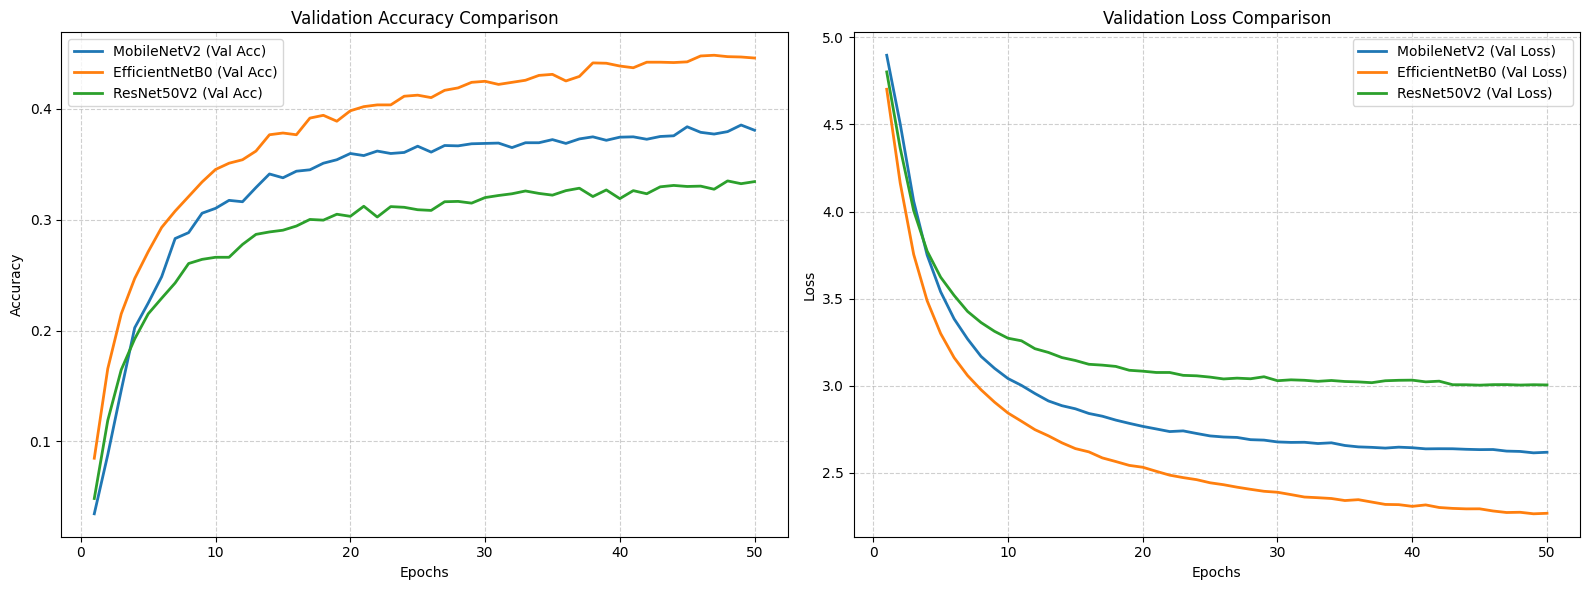

💾 บันทึกรูปกราฟเปรียบเทียบผลลัพธ์สำเร็จที่: /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/plant_model_comparison_plot.png

✅ บันทึกไฟล์ข้อมูลดิบสำหรับวิเคราะห์สถิติเรียบร้อยที่: /content/drive/MyDrive/Colab Notebooks/plants/data/dataset/chart_comparison_data.csv


,Model,Epoch,Validation Accuracy,Validation Loss,Train Accuracy,Train Loss
0,MobileNetV2,1,0.034753,4.897404,0.014492,5.163016
1,MobileNetV2,2,0.087977,4.503676,0.042451,4.801896
2,MobileNetV2,3,0.146212,4.059830,0.089864,4.407179
3,MobileNetV2,4,0.202567,3.750242,0.135071,4.052727
4,MobileNetV2,5,0.224796,3.539831,0.176183,3.749231


In [5]:
model_names = ['MobileNetV2', 'EfficientNetB0', 'ResNet50V2']
path_prefix = '/content/drive/MyDrive/Colab Notebooks/plants/data/dataset'

plt.figure(figsize=(16, 6))

# 1. แสดงกราฟ Validation Accuracy Comparison
plt.subplot(1, 2, 1)
for name in model_names:
    file_path = os.path.join(path_prefix, f'{name}_train_history.json')

    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            history = json.load(f)

        epochs = range(1, len(history['accuracy']) + 1)
        plt.plot(epochs, history['val_accuracy'], label=f'{name} (Val Acc)', linewidth=2)
    else:
        print(f"⚠️ ไม่พบไฟล์บันทึกประวัติการรันของ: {file_path}")

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. แสดงกราฟ Validation Loss Comparison
plt.subplot(1, 2, 2)
for name in model_names:
    file_path = os.path.join(path_prefix, f'{name}_train_history.json')

    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            history = json.load(f)

        epochs = range(1, len(history['loss']) + 1)
        plt.plot(epochs, history['val_loss'], label=f'{name} (Val Loss)', linewidth=2)

plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# บันทึกภาพผลการวิเคราะห์ไปใส่ในรูปเล่มบทความวิจัย
comparison_plot_path = os.path.join(path_prefix, 'plant_model_comparison_plot.png')
plt.savefig(comparison_plot_path)
plt.show()
print(f"💾 บันทึกรูปกราฟเปรียบเทียบผลลัพธ์สำเร็จที่: {comparison_plot_path}")

# 3. ทำการรวมข้อมูลดิบสำหรับการวาด Chart เพื่อ Export เป็นไฟล์ CSV
export_data = []

for name in model_names:
    file_path = os.path.join(path_prefix, f'{name}_train_history.json')

    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            history = json.load(f)

        epochs = range(1, len(history['val_accuracy']) + 1)
        for i, epoch in enumerate(epochs):
            export_data.append({
                'Model': name,
                'Epoch': epoch,
                'Validation Accuracy': history['val_accuracy'][i],
                'Validation Loss': history['val_loss'][i],
                'Train Accuracy': history['accuracy'][i],
                'Train Loss': history['loss'][i]
            })

if export_data:
    df_export = pd.DataFrame(export_data)
    csv_output_path = os.path.join(path_prefix, 'chart_comparison_data.csv')
    df_export.to_csv(csv_output_path, index=False)
    print(f"\n✅ บันทึกไฟล์ข้อมูลดิบสำหรับวิเคราะห์สถิติเรียบร้อยที่: {csv_output_path}")
    display(df_export.head())
else:
    print("\n⚠️ ไม่สามารถส่งออกไฟล์สถิติได้เนื่องจากไม่มีข้อมูลดิบ")

# SECTION 10: การประยุกต์ใช้เพื่อตรวจสอบเอกลักษณ์พรรณไม้แบบรายรูปภาพ (Single Inference & Community Knowledge Integration)

In [ ]:
from tensorflow.keras.preprocessing import image

def verify_plant_identity(image_path, model_path, class_indices_path):
    """
    ฟังก์ชันทำนายภาพพืชเดี่ยว และเชื่อมโยงคลังข้อมูลพฤกษศาสตร์เพื่อส่งเสริมการเรียนรู้ของชุมชนปทุมธานี
    """
    # 1. โหลดข้อมูลดัชนีคลาสพืช
    if not os.path.exists(class_indices_path):
        print(f"⚠️ ไม่พบไฟล์ดัชนีคลาสพืช: {class_indices_path}")
        return
    
    with open(class_indices_path, 'r', encoding='utf-8') as f:
        class_indices = json.load(f)
    
    # สร้างพิกัดย้อนกลับจากรหัสดัชนีเป็นชื่อพืชจริง
    labels_map = {v: k for k, v in class_indices.items()}

    # 2. ทำการโหลดแบบจำลองโมเดล
    if not os.path.exists(model_path):
        print(f"⚠️ ไม่พบโมเดลที่บันทึกไว้ที่: {model_path}")
        return
    
    # โหลดโดยไม่ระบุ Compile Option เพื่อให้ทำงานเร็วขึ้นตอนเรียกใช้งานอย่างเดียว
    model = tf.keras.models.load_model(model_path, compile=False)

    # 3. เตรียมไฟล์รูปภาพที่รับเข้าสู่แบบจำลอง
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # ขยายมิติมัดข้อมูล

    # 4. วิเคราะห์การทำนาย
    predictions = model.predict(img_array)
    predicted_idx = np.argmax(predictions[0])
    confidence_score = predictions[0][predicted_idx]
    
    plant_name_thai = labels_map[predicted_idx]
    
    print(f"\n🌿 ผลลัพธ์วิเคราะห์เอกลักษณ์พฤกษศาสตร์พืช:")
    print(f"----------------------------------------")
    print(f"ชื่อคลาสการคาดการณ์ (Prediction): {plant_name_thai.replace('_', ' ')}")
    print(f"ระดับความน่าจะเป็น (Confidence): {confidence_score * 100:.2f}%")
    print(f"----------------------------------------")

    # 5. การผนวกคลังความรู้ชุมชนจังหวัดปทุมธานี (Knowledge Management Integration)
    # ผู้วิจัยสามารถแก้ไขข้อมูลพฤกษศาสตร์ของพืชท้องถิ่นเพิ่มเติมได้ที่นี่ เพื่อเชื่อมโยงฐานข้อมูลการท่องเที่ยว/การศึกษา
    community_knowledge = {
        "บัวหลวง": "พรรณไม้สัญลักษณ์ประจำจังหวัดปทุมธานี สะท้อนวิถีชีวิตชาวสามโคกมาแต่อดีต ดอกบัวใช้ทำบุญ เมล็ดและฝักบัวรับประทานได้ มีพิพิธภัณฑ์บัว ณ มทร.ธัญบุรี เป็นแหล่งสะสมวิจัย",
        "ทองหลางลาย": "ต้นไม้ประจำจังหวัดปทุมธานี ใบอ่อนนิยมรับประทานเปรียบเสมือนผักแนมคู่กับชุมชน มีเอกลักษณ์เฉพาะตัวเวลาออกดอกบานสะพรั่งสีแดงส้ม",
        "กล้วยหอมทองปทุม": "ผลไม้สัญญลักษณ์ GI ประจำจังหวัดปทุมธานี ปลูกในบริเวณดินเปรี้ยวของที่ราบลุ่มแม่น้ำเจ้าพระยา รสชาติหวานหอม เนื้อส้มเนียนนุ่มเหนียว",
        "ข้าวหอมปทุมธานี_1": "พันธุ์ข้าวเศรษฐกิจ GI ที่ได้รับการยอมรับด้านความสุกเหนียวนุ่มและมีกลิ่นหอมเฉพาะตัว มีการจัดระบบการเรียนรู้การเกษตรยั่งยืนในระดับชุมชน"
    }
    
    # ค้นหาคีย์พืชว่าตรงกับคลังปทุมธานีหรือไม่
    found = False
    for key, desc in community_knowledge.items():
        if key in plant_name_thai:
            print(f"💡 [องค์ความรู้ชุมชนจังหวัดปทุมธานี]")
            print(f"รายละเอียดเพิ่มเติม: {desc}")
            found = True
            break
            
    if not found:
        print("💡 [ไม่มีบันทึกข้อมูลภูมิปัญญาท้องถิ่นเฉพาะสำหรับพรรณไม้ชนิดนี้]")

# ตัวอย่างโครงสร้างคำสั่งประมวลผล (เมื่อต้องการเรียกทำนายในงานจริง)
# verify_plant_identity(
#     image_path='sample_leaf.jpg',
#     model_path='/content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_EfficientNetB0.h5',
#     class_indices_path='/content/drive/MyDrive/Colab Notebooks/plants/data/dataset/class_indices.json'
# )

# SECTION 11: การแปลงแบบจำลองเพื่อเผยแพร่บนแพลตฟอร์มพกพา (Export Model to TensorFlow Lite)

In [ ]:
def export_to_tflite(h5_model_path, tflite_output_path):
    """
    แปลงโมเดลนามสกุล .h5 ที่มีความแม่นยำสูง ให้เป็นนามสกุล .tflite ที่มีขนาดเล็กลงมาก
    เพื่อนำไปใช้งานบนเว็บ (TensorFlow.js) หรืออุปกรณ์พกพา (Android/iOS) สำหรับชุมชนปทุมธานี
    """
    if not os.path.exists(h5_model_path):
        print(f"⚠️ ไม่พบไฟล์โมเดลต้นทาง: {h5_model_path}")
        return

    print(f"📦 กำลังเริ่มต้นแปลงโมเดล {os.path.basename(h5_model_path)}...")
    # โหลด Keras Model
    keras_model = tf.keras.models.load_model(h5_model_path, compile=False)

    # ตั้งค่า Converter
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

    # ทำการแปลงไฟล์
    tflite_model = converter.convert()

    # เขียนไฟล์โมเดลขนาดเบาลงพื้นที่เก็บข้อมูล
    with open(tflite_output_path, 'wb') as f:
        f.write(tflite_model)

    print(f"🎉 แปลงไฟล์สำเร็จ! โหลดโมเดลสำหรับติดตั้งในแอปพลิเคชันของคุณที่: {tflite_output_path}")
    print(f"น้ำหนักไฟล์โมเดลเดิม (.h5): {os.path.getsize(h5_model_path) / (1024 * 1024):.2f} MB")
    print(f"น้ำหนักไฟล์โมเดลเบา (.tflite): {os.path.getsize(tflite_output_path) / (1024 * 1024):.2f} MB")

# ตัวอย่างคำสั่งรันแปลงโมเดลไปติดตั้งบนสมาร์ทโฟน
# export_to_tflite(
#     h5_model_path='/content/drive/MyDrive/Colab Notebooks/plants/data/dataset/best_model_MobileNetV2.h5',
#     tflite_output_path='/content/drive/MyDrive/Colab Notebooks/plants/data/dataset/plant_model_mobilenet.tflite'
# )